In [1]:
import pandas as pd
import numpy as np
import unicodedata
import re
import torch
import torch.nn
from torch.utils.data import random_split, DataLoader

In [2]:
# Check if CUDA is available
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
print(f"Using device = {torch.get_default_device()}")

Using device = cuda:0


Load dataset

In [3]:
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('val.csv')

In [4]:
train_df.head()

,Unnamed: 0,Message ID,Subject,Message,Spam/Ham,split
0,0,0,christmas tree farm pictures,NaN,ham,0.038415
1,1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,0.696509
2,2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,0.587792
3,3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,-0.055438
4,5,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,-0.419658


In [5]:
feature_col = ['Subject','Message']
target = 'Spam/Ham'

train_df = train_df[feature_col + [target]]
val_df = val_df[feature_col + [target]]

train_df.head()

,Subject,Message,Spam/Ham
0,christmas tree farm pictures,NaN,ham
1,"vastar resources , inc .","gary , production from the high island larger ...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham
3,re : issue,fyi - see note below - already done .\nstella\...,ham
4,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham


Data Analyzing

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27284 entries, 0 to 27283
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Subject   27055 non-null  object
 1   Message   26932 non-null  object
 2   Spam/Ham  27284 non-null  object
dtypes: object(3)
memory usage: 639.6+ KB


In [7]:
train_df.describe()

,Subject,Message,Spam/Ham
count,27055,26932,27284
unique,20231,24451,2
top,#ERROR!,#ERROR!,spam
freq,194,122,13858


In [8]:
train_df.shape

(27284, 3)

In [9]:
train_df.isnull().sum()

,0
Subject,229
Message,352
Spam/Ham,0


In [10]:
train_df.isna().sum()

,0
Subject,229
Message,352
Spam/Ham,0


Text(0.5, 1.0, 'Count of Spam/Ham')

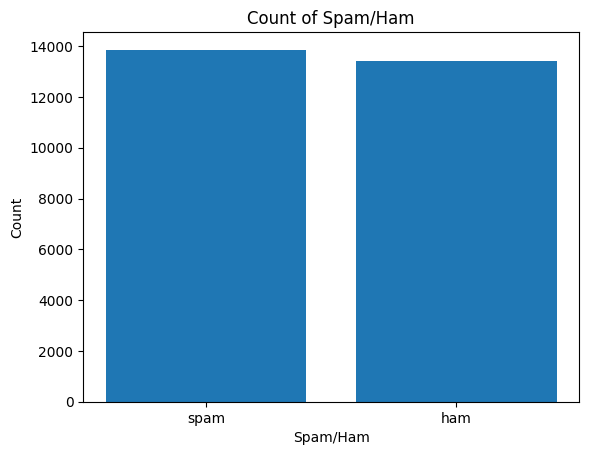

In [11]:
import matplotlib.pyplot as plt

counts = train_df['Spam/Ham'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Spam/Ham')
plt.ylabel('Count')
plt.title('Count of Spam/Ham')

Data preprocessing

In [12]:
#Xử lý dữ liệu NaN
train_df.replace([np.nan], '0', inplace=True)
val_df.replace([np.nan], '0', inplace=True)
train_df.isna().sum()

,0
Subject,0
Message,0
Spam/Ham,0


In [13]:
# train_set, test_set = torch.utils.data.random_split(train_df, [.85, .15], generator=torch.Generator(device=device).manual_seed(17))

# print(f"train examples = {len(train_set)}, test examples = {len(test_set)}")

# #tách features và target
# X_train = train_set.drop(columns=['Spam/Ham'])
# y_train = train_set['Spam/Ham']

# X_test = test_set.drop(columns=['Spam/Ham'])
# y_test = test_set['Spam/Ham']

X = train_df.drop(columns=['Spam/Ham'])
y = train_df['Spam/Ham']
X = X['Subject'] + ' ' + X['Message']

X_val = val_df.drop(columns=['Spam/Ham'])
X_val = X_val['Subject'] + ' ' + X_val['Message']
y_val = val_df['Spam/Ham']

In [14]:
X.head()

,0
0,christmas tree farm pictures 0
1,"vastar resources , inc . gary , production fro..."
2,calpine daily gas nomination - calpine daily g...
3,re : issue fyi - see note below - already done...
4,"mcmullen gas for 11 / 99 jackie ,\nsince the i..."


In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import FunctionTransformer

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X)
X_val = vectorizer.transform(X_val)



In [16]:
model = DecisionTreeClassifier()
model.fit(X_train, y)

DecisionTreeClassifier()

In [17]:
model.decision_path(X_val)
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

Evaluate

In [23]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_train)
accuracy_train = accuracy_score(y, y_pred)
print(f"Train Accuracy: {accuracy_train}")

y_pred_val = model.predict(X_val)
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"Val Accuracy: {accuracy_val}")

Train Accuracy: 1.0
Val Accuracy: 0.9653047989623865


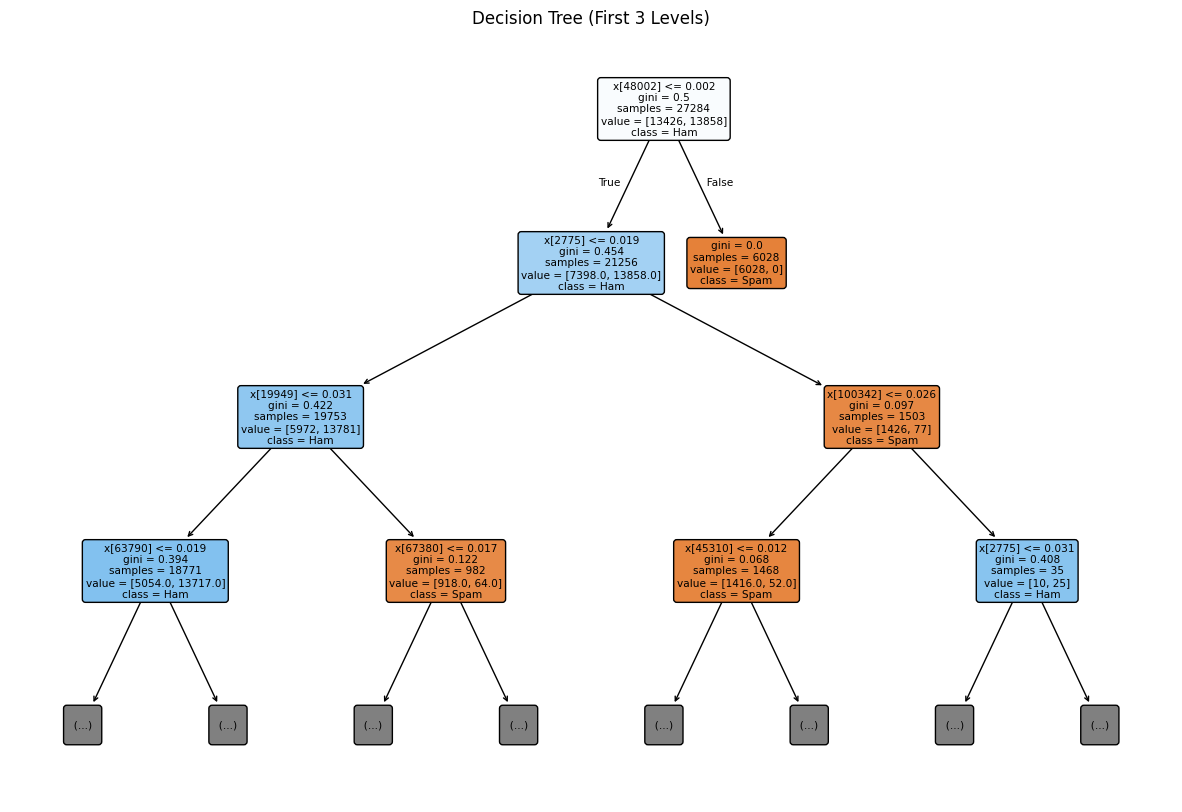

In [22]:
plt.figure(figsize=(15, 10)) # Increase figure size for better readability
plot_tree(model,
          max_depth=3, # Display only the first 3 levels of the tree
          class_names=['Spam','Ham'],
          filled=True,
          rounded=True)
plt.title('Decision Tree (First 3 Levels)')
plt.show()